# GHZ-127 Hardware Noise Benchmark (Standalone)

This notebook is dedicated to the GHZ hardware benchmark only.
It is independent from Iris/QML accuracy analysis.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
ASSETS_DIR = BASE_DIR / 'assets'
JSON_PATH = ASSETS_DIR / 'three_way_ghz127_comparison.json'
PNG_PATH = ASSETS_DIR / 'three_way_ghz127_comparison.png'

def run_benchmark(local_shots=1024, sim_shots=512, real_shots=256):
    cmd = [
        sys.executable,
        'compare_ghz_three_way.py',
        '--local-shots', str(local_shots),
        '--sim-shots', str(sim_shots),
        '--real-shots', str(real_shots),
    ]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)


## Optional: Re-run The Benchmark

Set `RUN_BENCHMARK = True` only when IBM Runtime connectivity/credentials are available.
The benchmark auto-skips real IBM execution when backend queue depth is non-zero (default threshold).


In [2]:
RUN_BENCHMARK = False
if RUN_BENCHMARK:
    run_benchmark(local_shots=1024, sim_shots=512, real_shots=256)
else:
    print('Skipping live benchmark run. Reading existing assets.')


Skipping live benchmark run. Reading existing assets.


In [3]:
if not JSON_PATH.exists():
    raise FileNotFoundError(f'Missing benchmark report: {JSON_PATH}')

report = json.loads(JSON_PATH.read_text(encoding='utf-8'))
print('generated_utc:', report['generated_utc'])
print('backend:', report['isa_backend_target']['name'])
print('isa depth:', report['isa_circuit']['depth'])
print('p_ghz_subspace local:', report['local']['p_ghz_subspace'])
print('p_ghz_subspace simulated:', report['simulated']['p_ghz_subspace'])
print('p_ghz_subspace real:', report['real']['p_ghz_subspace'])


generated_utc: 2026-03-08T23:49:54.568282+00:00
backend: ibm_fez
isa depth: 382
p_ghz_subspace local: 1.0
p_ghz_subspace simulated: 0.0
p_ghz_subspace real: 0.0


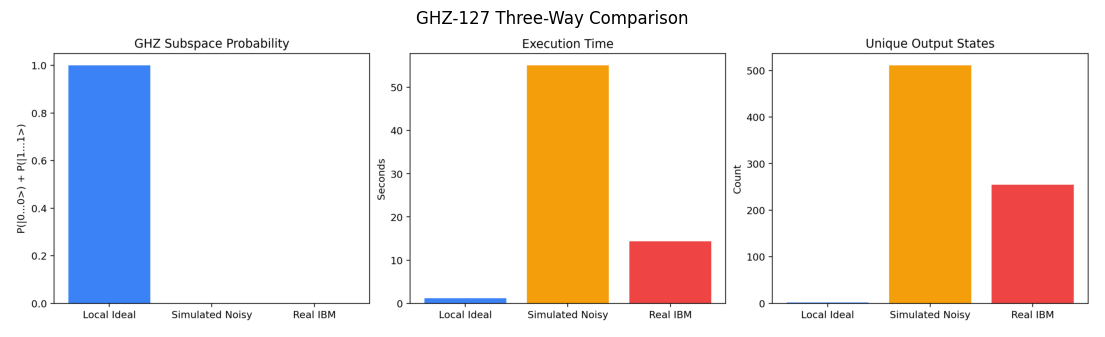

In [4]:
if not PNG_PATH.exists():
    raise FileNotFoundError(f'Missing benchmark chart: {PNG_PATH}')

img = plt.imread(PNG_PATH)
plt.figure(figsize=(14, 4))
plt.imshow(img)
plt.axis('off')
plt.title('GHZ-127 Three-Way Comparison')
plt.show()


## Interpretation

- This benchmark measures hardware noise behavior, not QML classification quality.
- For the existing run artifact, `p_ghz_subspace` collapses from ideal simulation to noisy/real targets.
- The reported GHZ-127 outcome is a decoherence-depth failure mode on current NISQ hardware.
